# LeetCode #704: Binary Search

https://leetcode.com/problems/binary-search/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (linear scan)** | $O(n)$ | $O(1)$ |
| **Binary Search** | $O(\log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (linear scan)
Scan left to right until finding the target or exhausting the array. Misses the sorted-array invariant entirely.

### Optimal: Binary Search ★
Classic binary search: maintain lo and hi, compute mid, compare `nums[mid]` to target, and halve the search space each iteration. Returns the index on hit, -1 on miss.

**Why this is better than Brute Force:** $O(\log n)$ vs $O(n)$ — the textbook example of exploiting sorted order.

**Constraints:**
* 1 <= nums.length <= 10^4
* -10^4 <= nums[i], target <= 10^4
* All values in nums are unique, sorted in ascending order

## Solutions

### C#

In [ ]:
public class Solution {
    public int Search(int[] nums, int target) {
        int lo = 0, hi = nums.Length - 1;
        while (lo <= hi) {
            int mid = lo + (hi - lo) / 2;
            if (nums[mid] == target) return mid;
            // Narrow toward the half that could contain target
            if (nums[mid] < target) lo = mid + 1;
            else hi = mid - 1;
        }
        return -1;
    }
}

### Python

In [ ]:
class Solution:
    def search(self, nums: list[int], target: int) -> int:
        lo, hi = 0, len(nums) - 1
        while lo <= hi:
            mid = lo + (hi - lo) // 2
            if nums[mid] == target:
                return mid
            # Narrow toward the half that could contain target
            if nums[mid] < target:
                lo = mid + 1
            else:
                hi = mid - 1
        return -1

### Go

In [ ]:
func search(nums []int, target int) int {
    lo, hi := 0, len(nums)-1
    for lo <= hi {
        mid := lo + (hi-lo)/2
        if nums[mid] == target {
            return mid
        }
        // Narrow toward the half that could contain target
        if nums[mid] < target {
            lo = mid + 1
        } else {
            hi = mid - 1
        }
    }
    return -1
}

### Rust

In [ ]:
impl Solution {
    pub fn search(nums: Vec<i32>, target: i32) -> i32 {
        let (mut lo, mut hi) = (0i32, nums.len() as i32 - 1);
        while lo <= hi {
            let mid = lo + (hi - lo) / 2;
            if nums[mid as usize] == target { return mid; }
            // Narrow toward the half that could contain target
            if nums[mid as usize] < target { lo = mid + 1; } else { hi = mid - 1; }
        }
        -1
    }
}

## Example Scenarios

**1. Common Case**
**Input:** nums=[-1,0,3,5,9,12], target=9
lo=0,hi=5 → mid=2, nums[2]=3<9 → lo=3. mid=4, nums[4]=9==9 → return 4.

**2. Slightly Complex**
**Input:** nums=[-1,0,3,5,9,12], target=2
lo=0,hi=5 → mid=2, 3>2 → hi=1. mid=0, -1<2 → lo=1. mid=1, 0<2 → lo=2. lo>hi → return -1.

**3. Edge Case: Time Factor**
**Input:** nums=[1,2,…,10^4], target=10^4 (last element)
Binary search reaches index 9999 in $\lfloor \log_2 10^4 \rfloor + 1 = 14$ steps. Every step moves lo right. Classic maximum-depth case.

**4. Edge Case: Space Factor**
**Input:** nums=[1], target=1
lo=hi=0 → mid=0, nums[0]=1==1 → return 0. Single element; O(1) space. One comparison.

**5. Almost-Impossible but Plausible**
**Input:** nums=[-10^4, -10^4+1, …, 10^4], target=-10^4 (smallest element)
Every step: nums[mid] > -10^4 → hi = mid-1. hi narrows leftward until lo=hi=0. Returns 0 in $O(\log n)$ steps — the symmetric counterpart to the last-element case.

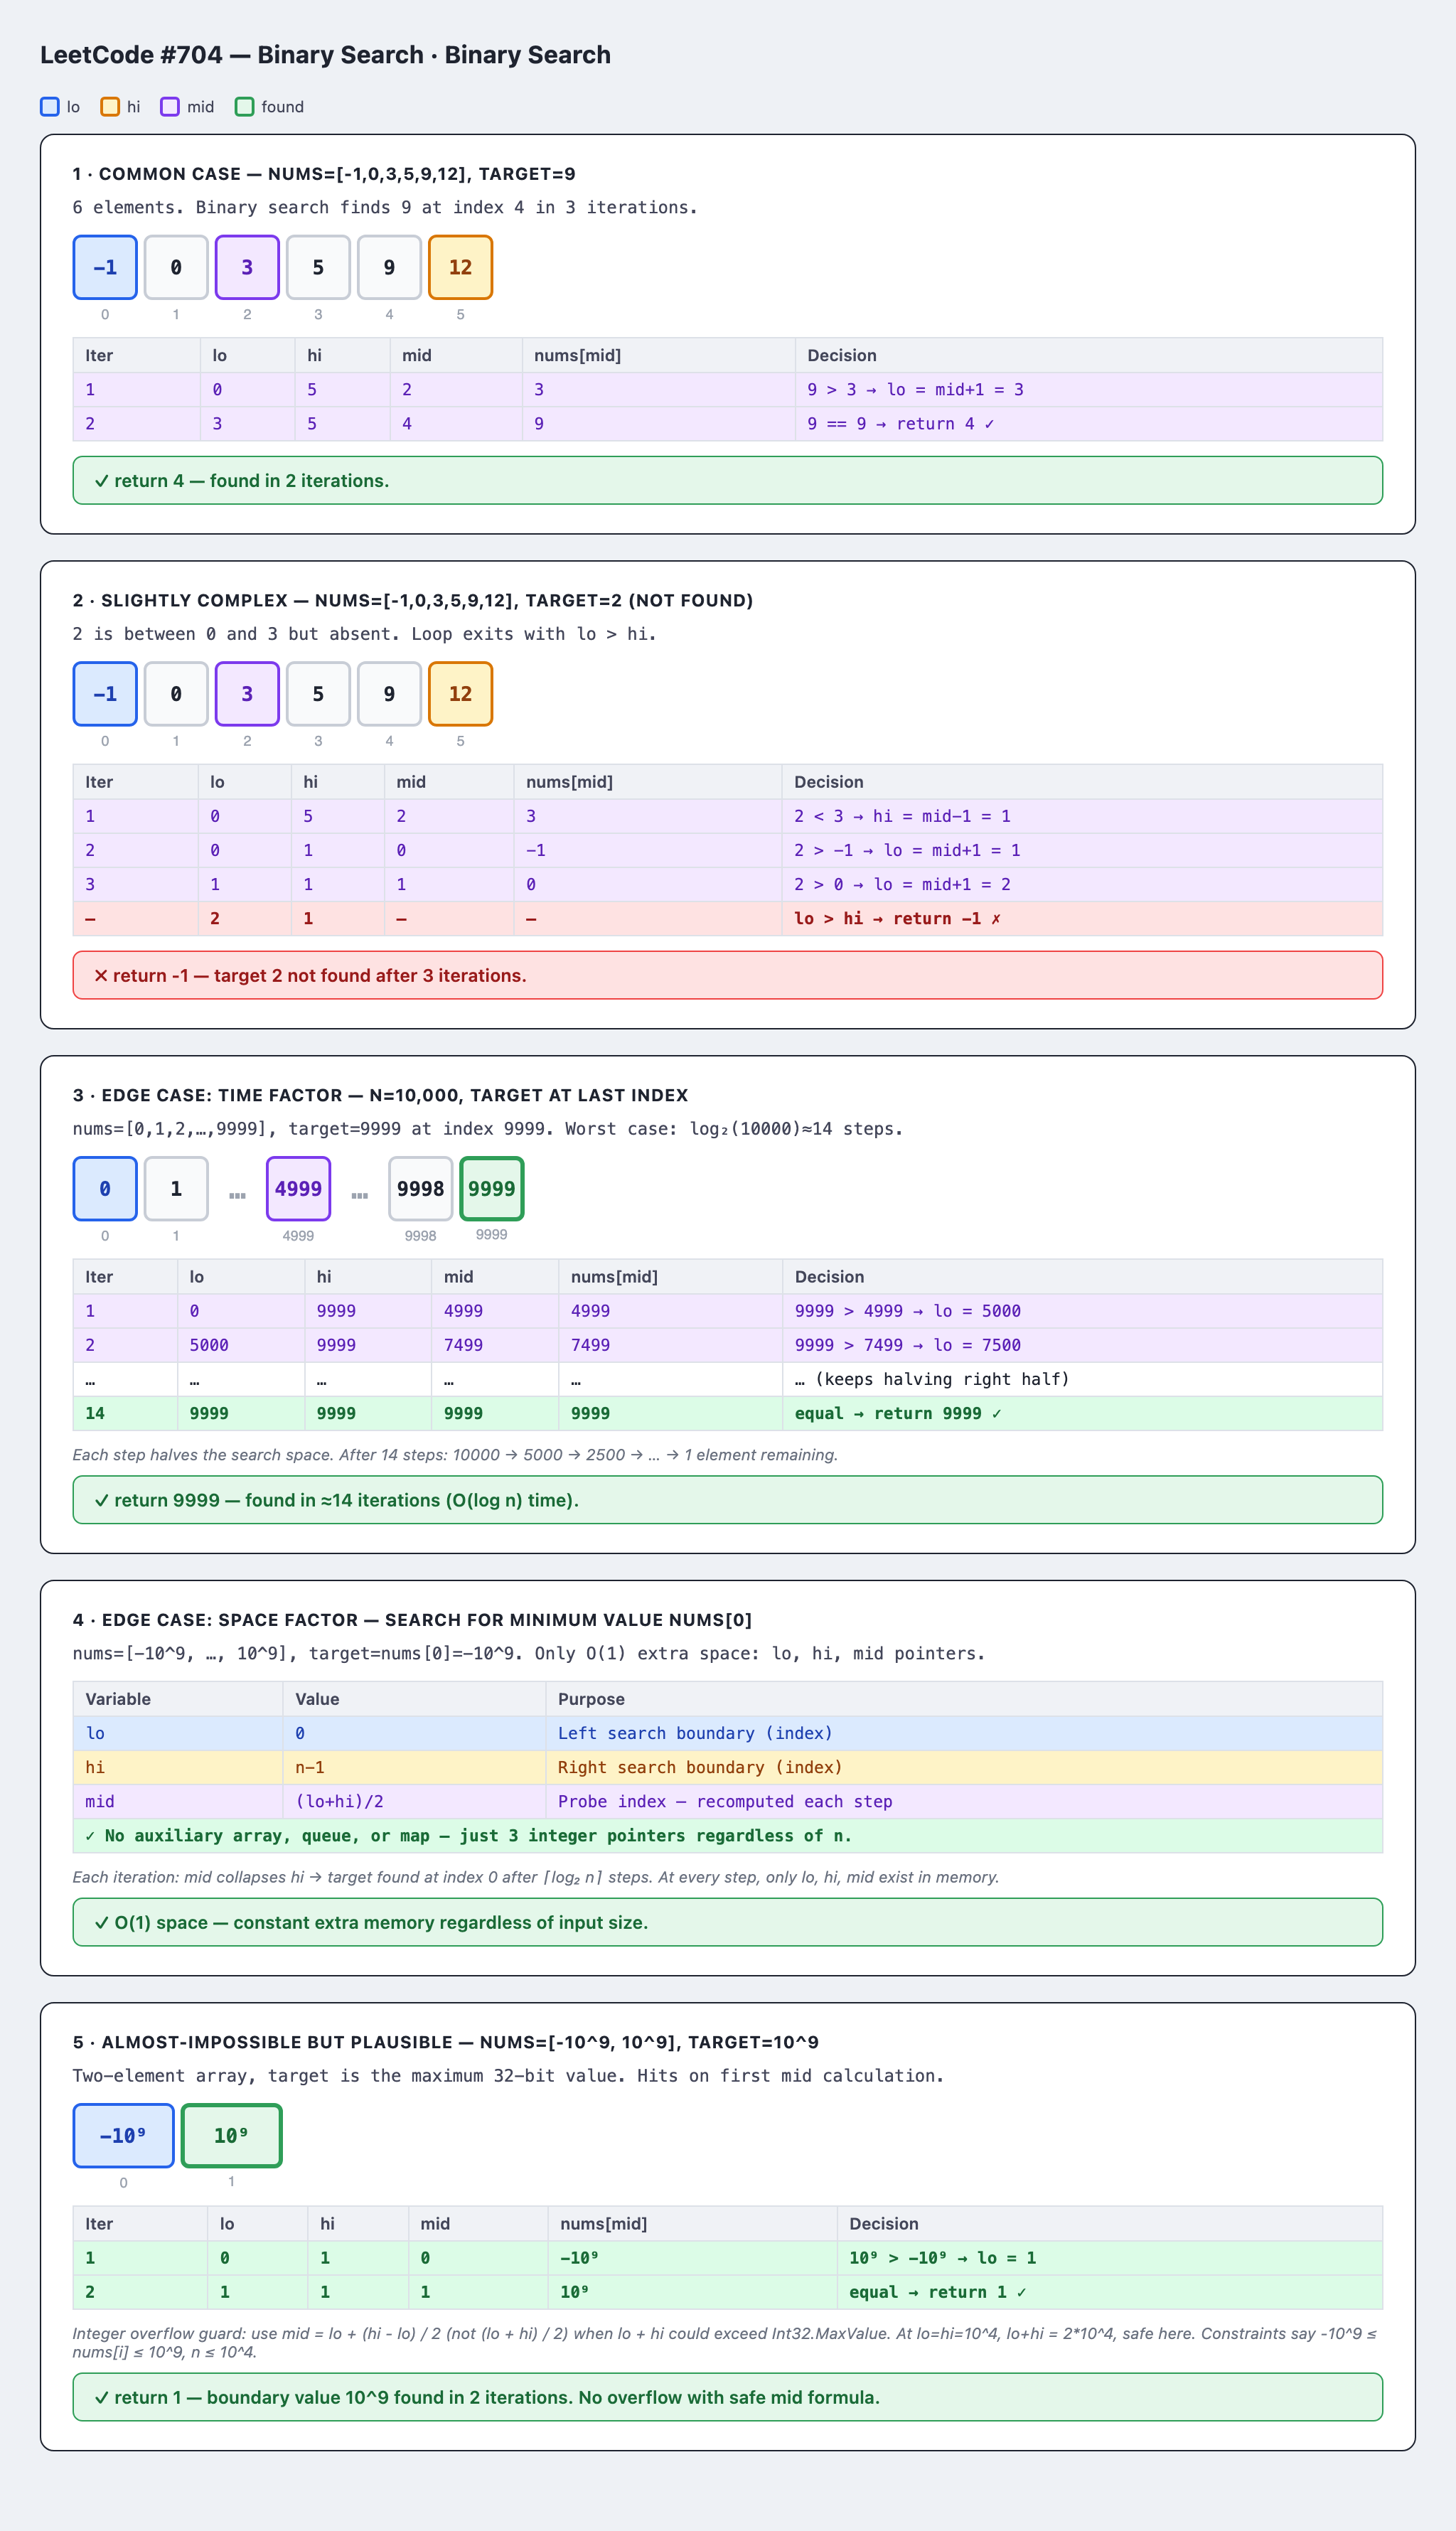